In [ ]:
 #import os
#os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
#print(f"x_train shape: {x_train.shape}")
#print(f"y_train shape: {y_train.shape}")


x_train = x_train[:5000]
y_train = y_train[:5000]
x_test = x_test[:1000]
y_test = y_test[:1000]

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Simple CNN
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
def train_model(batch_size, label):
    model = create_model()
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining using {label}")
    start = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=0
    )

    end = time.time()
    print(f"{label} Training Time: {end - start:.2f} seconds")

    return history

In [ ]:
# Full Batch Gradient Descent - Removed due to Out of Memory error
gd_history = train_model(batch_size=len(x_train), label="Full Batch GD")

# Stochastic Gradient Descent
sgd_history = train_model(batch_size=1, label="Stochastic GD")

# Mini-Batch SGD
mini_history = train_model(batch_size=64, label="Mini-Batch GD")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training using Full Batch GD
Full Batch GD Training Time: 10.43 seconds

Training using Stochastic GD
Stochastic GD Training Time: 129.59 seconds

Training using Mini-Batch GD
Mini-Batch GD Training Time: 7.81 seconds


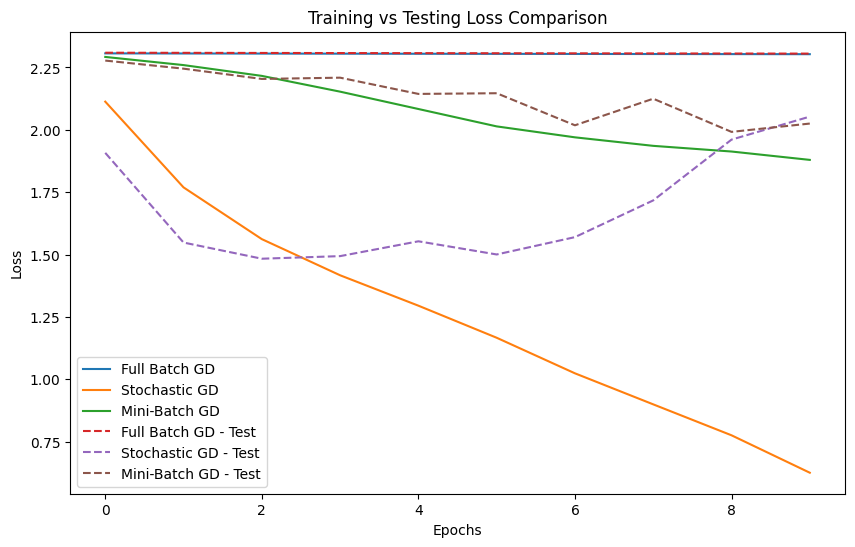

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(gd_history.history['loss'], label='Full Batch GD')
plt.plot(sgd_history.history['loss'], label='Stochastic GD')
plt.plot(mini_history.history['loss'], label='Mini-Batch GD')

# Testing (Validation) Loss
plt.plot(gd_history.history['val_loss'], '--', label='Full Batch GD - Test')
plt.plot(sgd_history.history['val_loss'], '--', label='Stochastic GD - Test')
plt.plot(mini_history.history['val_loss'], '--', label='Mini-Batch GD - Test')

plt.title("Training vs Testing Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



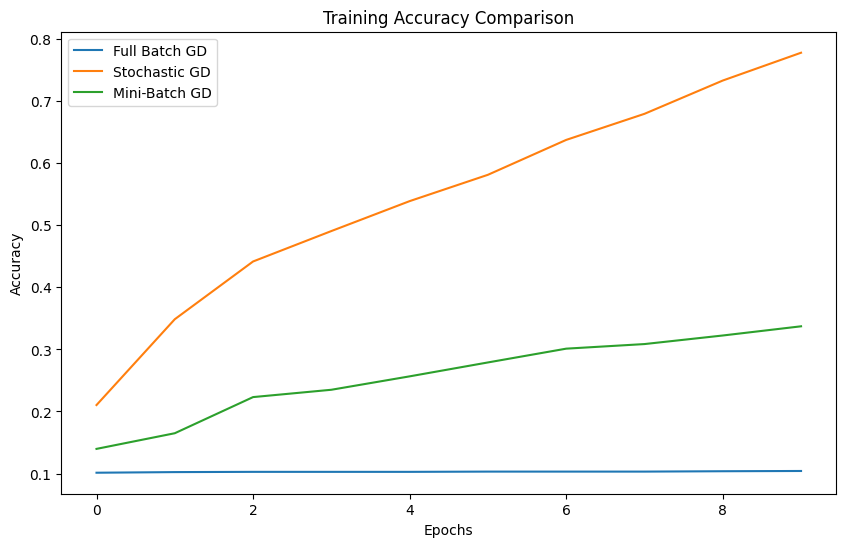

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(gd_history.history['accuracy'], label='Full Batch GD')
plt.plot(sgd_history.history['accuracy'], label='Stochastic GD')
plt.plot(mini_history.history['accuracy'], label='Mini-Batch GD')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()